# Data Discovery with DSI and NDP: Salton Sea Earthquake Swarm

This notebook demonstrates how to find, access, and analyze seismic data using data infrastructure tools.

**Complete workflow available at:**  
https://github.com/bpari004/UCOP_Automated-Earthquake-Catalog-Salton-Sea-Geothermal-Region/tree/main

## What You'll Learn

**Tools Used:**
- **DSI** (Data Science Infrastructure) - A Python library for querying data from multiple sources using a consistent interface
- **NDP** (National Data Platform) - A searchable catalog of open datasets from universities, research labs, and government agencies
- **Pelican** - A command-line tool for downloading files from distributed storage systems

**Workflow Overview:**  
DSI provides programmatic access to NDP's catalog through Python commands. 
Search results include metadata and download links for each dataset.

**Dataset:** 29 seismic stations that recorded the August 2012 Brawley earthquake swarm near California's Salton Sea

In [1]:
%matplotlib inline

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Import all required libraries
# ══════════════════════════════════════════════════════════════════════════════

# Data discovery and handling
from dsi.dsi import DSI
import pandas as pd
import numpy as np

# System and file operations
import subprocess
import os
import glob
import ssl
from pathlib import Path
from itertools import groupby
from IPython.display import Image, display

# Seismic data processing
from obspy import read, Stream, UTCDateTime

# Visualization
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

# Spatial analysis
from scipy.spatial.distance import pdist

print("✓ All libraries loaded")

✓ All libraries loaded


## Step 1: Search the Data Catalog

We'll use DSI to search the National Data Platform for seismic datasets.

**How it works:**
1. DSI connects to NDP's search API
2. You provide search terms (keywords, organization, creator)
3. DSI returns matching datasets with their metadata

**Parameters explained:**
- `keywords` - Search across dataset titles, descriptions, and tags
- `organization` - Filter by the institution that published the data
- `creator` - Filter by the researcher who created the dataset
- `limit` - Maximum number of results to return

In [3]:
print("=" * 60)
print("Step 1: Searching for Datasets")
print("=" * 60)

# Connect to NDP and search for Salton Sea seismic data
dsi = DSI(
    backend_name="NDP",  # Use the National Data Platform
    params={
        "keywords": "Salton Sea seismic",  # What we're looking for
        "organization": "UCR Earth and Planetary Sciences",  # Where it came from
        "creator": "Binayak Parida",  # Who created it
        "limit": 10  # Return up to 10 matches
    }
)

print("\n✓ Connected to NDP")
print("✓ Search completed")

# Show what information DSI retrieved
print("\n" + "=" * 60)
print("Available Information:")
print("=" * 60)
dsi.list()

print("✓ Step 1 Complete - Found matching datasets")

Step 1: Searching for Datasets
Created an instance of DSI with the NDP read-only backend

✓ Connected to NDP
✓ Search completed

Available Information:
Table: datasets
  - num of columns: 14
  - num of rows: 1

Table: resources
  - num of columns: 9
  - num of rows: 1


✓ Step 1 Complete - Found matching datasets


## Understanding DSI's Output

DSI organizes results into two tables:

**1. `datasets` table** - Overview information
- One row per dataset
- Contains: id, title, creator, organization, notes (description), created/modified dates, 
  tags, license, and number of resources

**2. `resources` table** - File details
- One row per downloadable file
- Contains: resource_id, resource_name, format, size, url (download link), issue_date,
  and dataset_id (links to parent dataset)

**Key Point:** DSI only retrieves *metadata* (information about the files).
The actual data files are downloaded separately in Step 4.

## Step 2: Examine Dataset Information

Let's look at what we found. The results are returned as pandas DataFrames, allowing you to filter, sort, and analyze the metadata like any other dataset.

In [4]:
print("\n" + "=" * 60)
print("Step 2: Examining Search Results")
print("=" * 60)

# Get search results as a pandas DataFrame
datasets_df = dsi.get_table("datasets", collection=True)

print(f"\n✓ Found {len(datasets_df)} dataset(s)")

# Display key information about the first result
if len(datasets_df) > 0:
    dataset = datasets_df.iloc[0]
    print("\n" + "=" * 60)
    print("Dataset Summary:")
    print("=" * 60)
    print(f"  Title:        {dataset['title']}")
    print(f"  Organization: {dataset['organization']}")
    print(f"  Creator:      {dataset['creator']}")
    print(f"  Files:        {dataset['num_resources']} file(s)")
    print(f"  Published:    {dataset['created']}")

# Show formatted table with selected columns
print("\n" + "=" * 60)
print("Dataset Details:")
print("=" * 60)
dsi.display(
    'datasets',
    num_rows=5,
    display_cols=['title', 'organization', 'creator', 'num_resources']
)

print("✓ Step 2 Complete - Dataset information retrieved")


Step 2: Examining Search Results
Storing all data for the table: datasets as a collection

✓ Found 1 dataset(s)

Dataset Summary:
  Title:        Salton Sea Seismic Data
  Organization: UCR Earth and Planetary Sciences
  Creator:      Binayak Parida
  Files:        1 file(s)
  Published:    2026-04-30T20:21:38.501502

Dataset Details:

Table: datasets
                  title                     organization        creator  num_resources
Salton Sea Seismic Data UCR Earth and Planetary Sciences Binayak Parida              1

✓ Step 2 Complete - Dataset information retrieved


## Step 3: Get Download Links

Now we'll access the `resources` table to see individual files and their download URLs.
All download links are provided programmatically for direct file retrieval.

In [5]:
print("\n" + "=" * 60)
print("Step 3: Getting Download Links")
print("=" * 60)

# Get the dataset ID and retrieve its files
dataset_id = datasets_df.iloc[0]['id']
resources_df = dsi.get_table("resources", collection=True)

# Filter to show only files from our selected dataset
dataset_resources = resources_df[resources_df['dataset_id'] == dataset_id]

print(f"\n✓ Found {len(dataset_resources)} file(s) available for download")

# Display available files and their URLs
print("\n" + "=" * 60)
print("Available Files:")
print("=" * 60)

for idx, (_, row) in enumerate(dataset_resources.iterrows(), 1):
    print(f"\n{idx}. {row['resource_name']}")
    print(f"   Download URL: {row['url']}")

# Use these files for the next step
resources_df = dataset_resources

print("\n✓ Step 3 Complete - Download links ready")


Step 3: Getting Download Links
Storing all data for the table: resources as a collection

✓ Found 1 file(s) available for download

Available Files:

1. Salton Sea Seismic Waveforms
   Download URL: osdf:///ndp/public/ucr_seis/Data_Salton

✓ Step 3 Complete - Download links ready


## Step 4: Download the Data

Now we'll download the actual files using Pelican, a command-line tool designed for
retrieving data from OSDF (Open Science Data Federation) storage.

**What's happening:**
1. We take the URL from Step 3
2. Pelican connects to the storage system
3. Files are copied to your local computer

The `--recursive` flag downloads entire directories, including subdirectories.

**Note:** This downloads ~2GB of seismic waveforms and takes about 6 minutes.

In [6]:
print("\n" + "=" * 60)
print("Step 4: Downloading Dataset")
print("=" * 60)

PELICAN = os.path.expanduser("~/bin/pelican")
osdf_path = 'osdf:///ndp/public/ucr_seis/Data_Salton'
data_dir  = './Data_Salton'
os.makedirs(data_dir, exist_ok=True)

# Check if data already exists
existing_files = list(Path(data_dir).rglob('*'))
if len(existing_files) > 10:  # Adjust threshold as needed
    print(f"✓ Found {len(existing_files)} existing files in {data_dir}/")
    print("Skipping download. Delete the directory to re-download.\n")
else:
    print(f"Source: {osdf_path}")
    print(f"Destination: {data_dir}\n")
    print("Starting download...")
    
    def download_via_pelican_cli(osdf_path, local_dir):
        cmd = [PELICAN, "object", "get", "-r", osdf_path, local_dir]
        print("Command:", " ".join(cmd), "\n")
        return subprocess.run(cmd, capture_output=True, text=True, check=True)
    
    try:
        result = download_via_pelican_cli(osdf_path, data_dir)
        if result.stdout:
            print(result.stdout)
        print("✓ Download complete")
    except subprocess.CalledProcessError as e:
        print(f"✗ Download failed: {e}")
        if e.stderr:
            print(f"Error details: {e.stderr}")

print(f"\n✓ Step 4 Complete - Files in {data_dir}/")


Step 4: Downloading Dataset
✓ Found 714 existing files in ./Data_Salton/
Skipping download. Delete the directory to re-download.


✓ Step 4 Complete - Files in ./Data_Salton/


## Step 5: Load Station Information

The dataset includes a CSV file listing all seismic stations and their locations.
Each station has 3 channels (East, North, Vertical), so we'll deduplicate to get
one row per station for mapping purposes.

In [7]:
print("\n" + "=" * 60)
print("Step 5: Loading Station Metadata")
print("=" * 60)

# Load station list from downloaded files
station_file = './Data_Salton/config/station_list.csv'
df_all = pd.read_csv(station_file)

print(f"✓ Loaded {len(df_all)} channel records from CSV")
print("\nPreview:")
print(df_all.head())

# Deduplicate - keep one row per station (not per channel)
df_sta = df_all.groupby(['network', 'station']).agg({
    'latitude': 'first',
    'longitude': 'first',
    'elevation_m': 'first',
    'start': 'min',  # Earliest recording time
    'end': 'max'     # Latest recording time
}).reset_index()

df_sta.columns = ['network', 'station', 'latitude', 'longitude', 'elevation_m', 'start', 'end']

print(f"\n✓ Consolidated to {len(df_sta)} unique stations")
print("\nStations by network:")
print(df_sta['network'].value_counts())

print(f"\n✓ Step 5 Complete - {len(df_sta)} stations loaded")


Step 5: Loading Station Metadata
✓ Loaded 87 channel records from CSV

Preview:
  network station  location channel  latitude  longitude  elevation_m  \
0      CI     BOM       NaN     HHE  33.36465 -115.72963        -54.0   
1      CI     BOM       NaN     HHN  33.36465 -115.72963        -54.0   
2      CI     BOM       NaN     HHZ  33.36465 -115.72963        -54.0   
3      CI     BTC       NaN     HHE  33.01213 -115.21987         39.0   
4      CI     BTC       NaN     HHN  33.01213 -115.21987         39.0   

   sample_rate                        start                          end  
0        100.0  2011-04-27T16:50:00.000000Z  2021-08-03T14:00:00.000000Z  
1        100.0  2011-04-27T16:50:00.000000Z  2021-08-03T14:00:00.000000Z  
2        100.0  2011-04-27T16:50:00.000000Z  2021-08-03T14:00:00.000000Z  
3        100.0  2010-10-06T15:00:00.000000Z  2012-08-31T20:07:00.000000Z  
4        100.0  2010-10-06T15:00:00.000000Z  2012-08-31T20:07:00.000000Z  

✓ Consolidated to 29 unique s

## Step 6: Analyze Network Geometry

Calculate basic statistics about the seismic array:
- Geographic coverage (lat/lon bounds)
- Elevation range
- Inter-station distances

These metrics help assess the network's ability to detect and locate earthquakes.

In [8]:
print("\n" + "=" * 60)
print("Step 6: Network Statistics")
print("=" * 60)

# Calculate geographic extent
print("Geographic Coverage:")
print(f"  Latitude:  {df_sta['latitude'].min():.4f}° to {df_sta['latitude'].max():.4f}°")
print(f"  Longitude: {df_sta['longitude'].min():.4f}° to {df_sta['longitude'].max():.4f}°")
print(f"  Elevation: {df_sta['elevation_m'].min():.1f}m to {df_sta['elevation_m'].max():.1f}m")

# Calculate distances between all station pairs
coords = df_sta[['latitude', 'longitude']].values
distances_deg = pdist(coords, metric='euclidean')
distances_km = distances_deg * 111  # Convert degrees to km (approximate)

print(f"\nInter-Station Distances:")
print(f"  Mean:    {np.mean(distances_km):.1f} km")
print(f"  Median:  {np.median(distances_km):.1f} km")
print(f"  Min:     {np.min(distances_km):.1f} km")
print(f"  Max:     {np.max(distances_km):.1f} km")

# Count stations by network operator
print(f"\nNetwork Composition:")
for net, group in df_sta.groupby('network'):
    print(f"  {net}: {len(group)} stations ({len(group)/len(df_sta)*100:.1f}%)")

print(f"\n✓ Step 6 Complete - Statistics calculated")


Step 6: Network Statistics
Geographic Coverage:
  Latitude:  32.6501° to 33.4852°
  Longitude: -116.1095° to -115.0719°
  Elevation: -63.0m to 906.0m

Inter-Station Distances:
  Mean:    47.8 km
  Median:  44.6 km
  Min:     3.8 km
  Max:     121.4 km

Network Composition:
  CI: 11 stations (37.9%)
  XD: 17 stations (58.6%)
  ZY: 1 stations (3.4%)

✓ Step 6 Complete - Statistics calculated


## Step 7: Understanding the Network

This 29-station array monitored the August 2012 Brawley earthquake swarm in California's
Salton Sea region - where the San Andreas and Imperial faults intersect near active
geothermal power plants.

### Station Networks
| Code | Count | Type | Rate | Operator |
|------|-------|------|------|----------|
| **CI** | 11 | Broadband (HH) | 100 Hz | Caltech / SCEDC |
| **XD** | 17 | Broadband (BH) | 40 Hz | IRIS PASSCAL |
| **ZY** | 1 | Short-period (EH) | 100 Hz | Temporary |

### Purpose
The dense XD array provides focused coverage of the geothermal field (~3-5 km spacing),
while permanent CI stations supply regional context. Together they can detect earthquakes
as small as M0.5 and locate them within ~500m horizontally.

This swarm included over 2,000 earthquakes in August 2012.

In [9]:
print("\n" + "=" * 60)
print("Step 7: Network Description")
print("=" * 60)

# Show network composition with technical details
print("\nNetwork Composition:")
print("-" * 60)
for net, group in df_sta.groupby('network'):
    count = len(group)
    pct = count / len(df_sta) * 100
    
    # Get channel info from original data
    channels = df_all[df_all['network'] == net]['channel'].unique()
    channel_type = channels[0][:2] if len(channels) > 0 else 'Unknown'
    sample_rate = df_all[df_all['network'] == net]['sample_rate'].iloc[0]
    
    print(f"  {net}: {count:2d} stations ({pct:5.1f}%) | {channel_type} @ {sample_rate:.0f} Hz")

# Geographic extent
print("\nSpatial Coverage:")
print("-" * 60)
lat_span = df_sta['latitude'].max() - df_sta['latitude'].min()
lon_span = df_sta['longitude'].max() - df_sta['longitude'].min()
print(f"  Latitude:  {df_sta['latitude'].min():.4f}° to {df_sta['latitude'].max():.4f}° ({lat_span:.2f}° span)")
print(f"  Longitude: {df_sta['longitude'].min():.4f}° to {df_sta['longitude'].max():.4f}° ({lon_span:.2f}° span)")
print(f"  Elevation: {df_sta['elevation_m'].min():.1f}m to {df_sta['elevation_m'].max():.1f}m")
print(f"  Array size: ~{lat_span * 111:.0f} km (N-S) × {lon_span * 111:.0f} km (E-W)")

# Context
print("\nScientific Context:")
print("-" * 60)
print("  CI (Caltech): Permanent regional monitoring network")
print("  XD (PASSCAL): Temporary dense array for geothermal study")
print("  ZY: Additional short-period coverage")
print()
print("  Target: Brawley earthquake swarm (2,000+ events in Aug 2012)")
print("  Location: San Andreas - Imperial fault intersection")
print("  Setting: Active geothermal fields in Salton Sea basin")

# Performance specs
print("\nDetection Capability:")
print("-" * 60)
print(f"  Minimum magnitude: M 0.5-1.0")
print(f"  Location accuracy: ~0.5 km horizontal, ~1-2 km vertical")
print(f"  Primary use: Swarm characterization and induced seismicity monitoring")

print(f"\n✓ Step 7 Complete")


Step 7: Network Description

Network Composition:
------------------------------------------------------------
  CI: 11 stations ( 37.9%) | HH @ 100 Hz
  XD: 17 stations ( 58.6%) | BH @ 40 Hz
  ZY:  1 stations (  3.4%) | EH @ 100 Hz

Spatial Coverage:
------------------------------------------------------------
  Latitude:  32.6501° to 33.4852° (0.84° span)
  Longitude: -116.1095° to -115.0719° (1.04° span)
  Elevation: -63.0m to 906.0m
  Array size: ~93 km (N-S) × 115 km (E-W)

Scientific Context:
------------------------------------------------------------
  CI (Caltech): Permanent regional monitoring network
  XD (PASSCAL): Temporary dense array for geothermal study
  ZY: Additional short-period coverage

  Target: Brawley earthquake swarm (2,000+ events in Aug 2012)
  Location: San Andreas - Imperial fault intersection
  Setting: Active geothermal fields in Salton Sea basin

Detection Capability:
------------------------------------------------------------
  Minimum magnitude: M 0

## Step 8: Map the Station Network

Visualize station locations on a map to understand array geometry.
Stations are colored and shaped by network type for easy identification.

- **CI** (cyan triangles): 11 broadband stations, 100 Hz
- **XD** (orange circles): 17 broadband stations, 40 Hz  
- **ZY** (green square): 1 short-period station, 100 Hz

In [10]:
def plot_station_network_map(df_sta, data_dir):
    """Generate map showing station locations and network coverage"""
    
    # Setup map projection
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(14, 12))
    ax = fig.add_subplot(1, 1, 1, projection=proj)
    
    # Focus on Salton Sea region
    ax.set_extent([-116.35, -115.00, 32.55, 33.60], crs=proj)
    
    # Add satellite imagery basemap
    print("  Adding basemap...")
    try:
        terrain = cimgt.GoogleTiles(style='satellite')
        ax.add_image(terrain, 10)
    except Exception as e:
        print(f"    Satellite unavailable, using fallback")
        ax.add_feature(cfeature.LAND, facecolor='#d6cfc4')
        ax.add_feature(cfeature.OCEAN, facecolor='#a8c8e8')
    
    # Add political boundaries
    ax.add_feature(cfeature.STATES.with_scale('10m'), 
                   edgecolor='white', linewidth=1.2, zorder=3, alpha=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), 
                   edgecolor='white', linewidth=1.8, zorder=3)
    
    # Plot stations with network-specific symbols
    print("  Plotting stations...")
    markers = {'CI': '^', 'XD': 'o', 'ZY': 's'}  # Triangle, circle, square
    colors = {'CI': '#00e5ff', 'XD': '#ff6d00', 'ZY': '#69f0ae'}  # Cyan, orange, green
    
    for net, group in df_sta.groupby('network'):
        ax.scatter(group['longitude'], group['latitude'], 
                  c=colors.get(net, 'gray'), 
                  s=180, 
                  marker=markers.get(net, 'o'),
                  edgecolors='white', 
                  linewidths=1.0, 
                  transform=proj, 
                  zorder=8)
    
    # Add station name labels
    for _, row in df_sta.iterrows():
        ax.annotate(
            row['station'], 
            xy=(row['longitude'], row['latitude']), 
            xytext=(0, 7), 
            textcoords='offset points', 
            fontsize=7, 
            ha='center', 
            va='bottom',
            color='white', 
            fontweight='bold',
            xycoords=proj._as_mpl_transform(ax),
            zorder=9,
            path_effects=[pe.withStroke(linewidth=2, foreground='black')]
        )
    
    # Add coordinate grid
    gl = ax.gridlines(draw_labels=True, linewidth=0.6, 
                     color='white', alpha=0.4, linestyle='--', zorder=2)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'color': 'white', 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'color': 'white', 'weight': 'bold'}
    
    # Create legend
    handles = [
        mlines.Line2D([], [], marker='^', color='w', 
                     markerfacecolor='#00e5ff', markersize=11, 
                     markeredgewidth=1, markeredgecolor='white',
                     label=f'CI (Caltech) - {len(df_sta[df_sta["network"]=="CI"])} stations | HH @ 100Hz',
                     linestyle='None'),
        mlines.Line2D([], [], marker='o', color='w', 
                     markerfacecolor='#ff6d00', markersize=11, 
                     markeredgewidth=1, markeredgecolor='white',
                     label=f'XD (PASSCAL) - {len(df_sta[df_sta["network"]=="XD"])} stations | BH @ 40Hz',
                     linestyle='None'),
        mlines.Line2D([], [], marker='s', color='w', 
                     markerfacecolor='#69f0ae', markersize=11, 
                     markeredgewidth=1, markeredgecolor='white',
                     label=f'ZY (Short-period) - {len(df_sta[df_sta["network"]=="ZY"])} station | EH @ 100Hz',
                     linestyle='None'),
    ]
    
    legend = ax.legend(handles=handles, 
                      loc='upper right', 
                      fontsize=9, 
                      framealpha=0.95,
                      edgecolor='black',
                      fancybox=True,
                      title='Seismic Networks',
                      title_fontsize=10)
    legend.get_frame().set_facecolor('white')
    
    # Add title
    ax.set_title(
        'Salton Sea Seismic Network - August 2012 Brawley Swarm\n' +
        f'{len(df_sta)} Stations Monitoring Geothermal Field & Active Faults', 
        fontsize=13, 
        fontweight='bold', 
        pad=12,
        color='white',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7)
    )
        
    # Save figure
    out_path = os.path.join(data_dir, 'station_network_map.png')
    plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"\n  Saved: {out_path}")
    
    # Display the saved image
    display(Image(filename=out_path))
    
    return out_path


Step 8: Creating Network Map
  Adding basemap...
  Plotting stations...

  Saved: ./Data_Salton/station_network_map.png


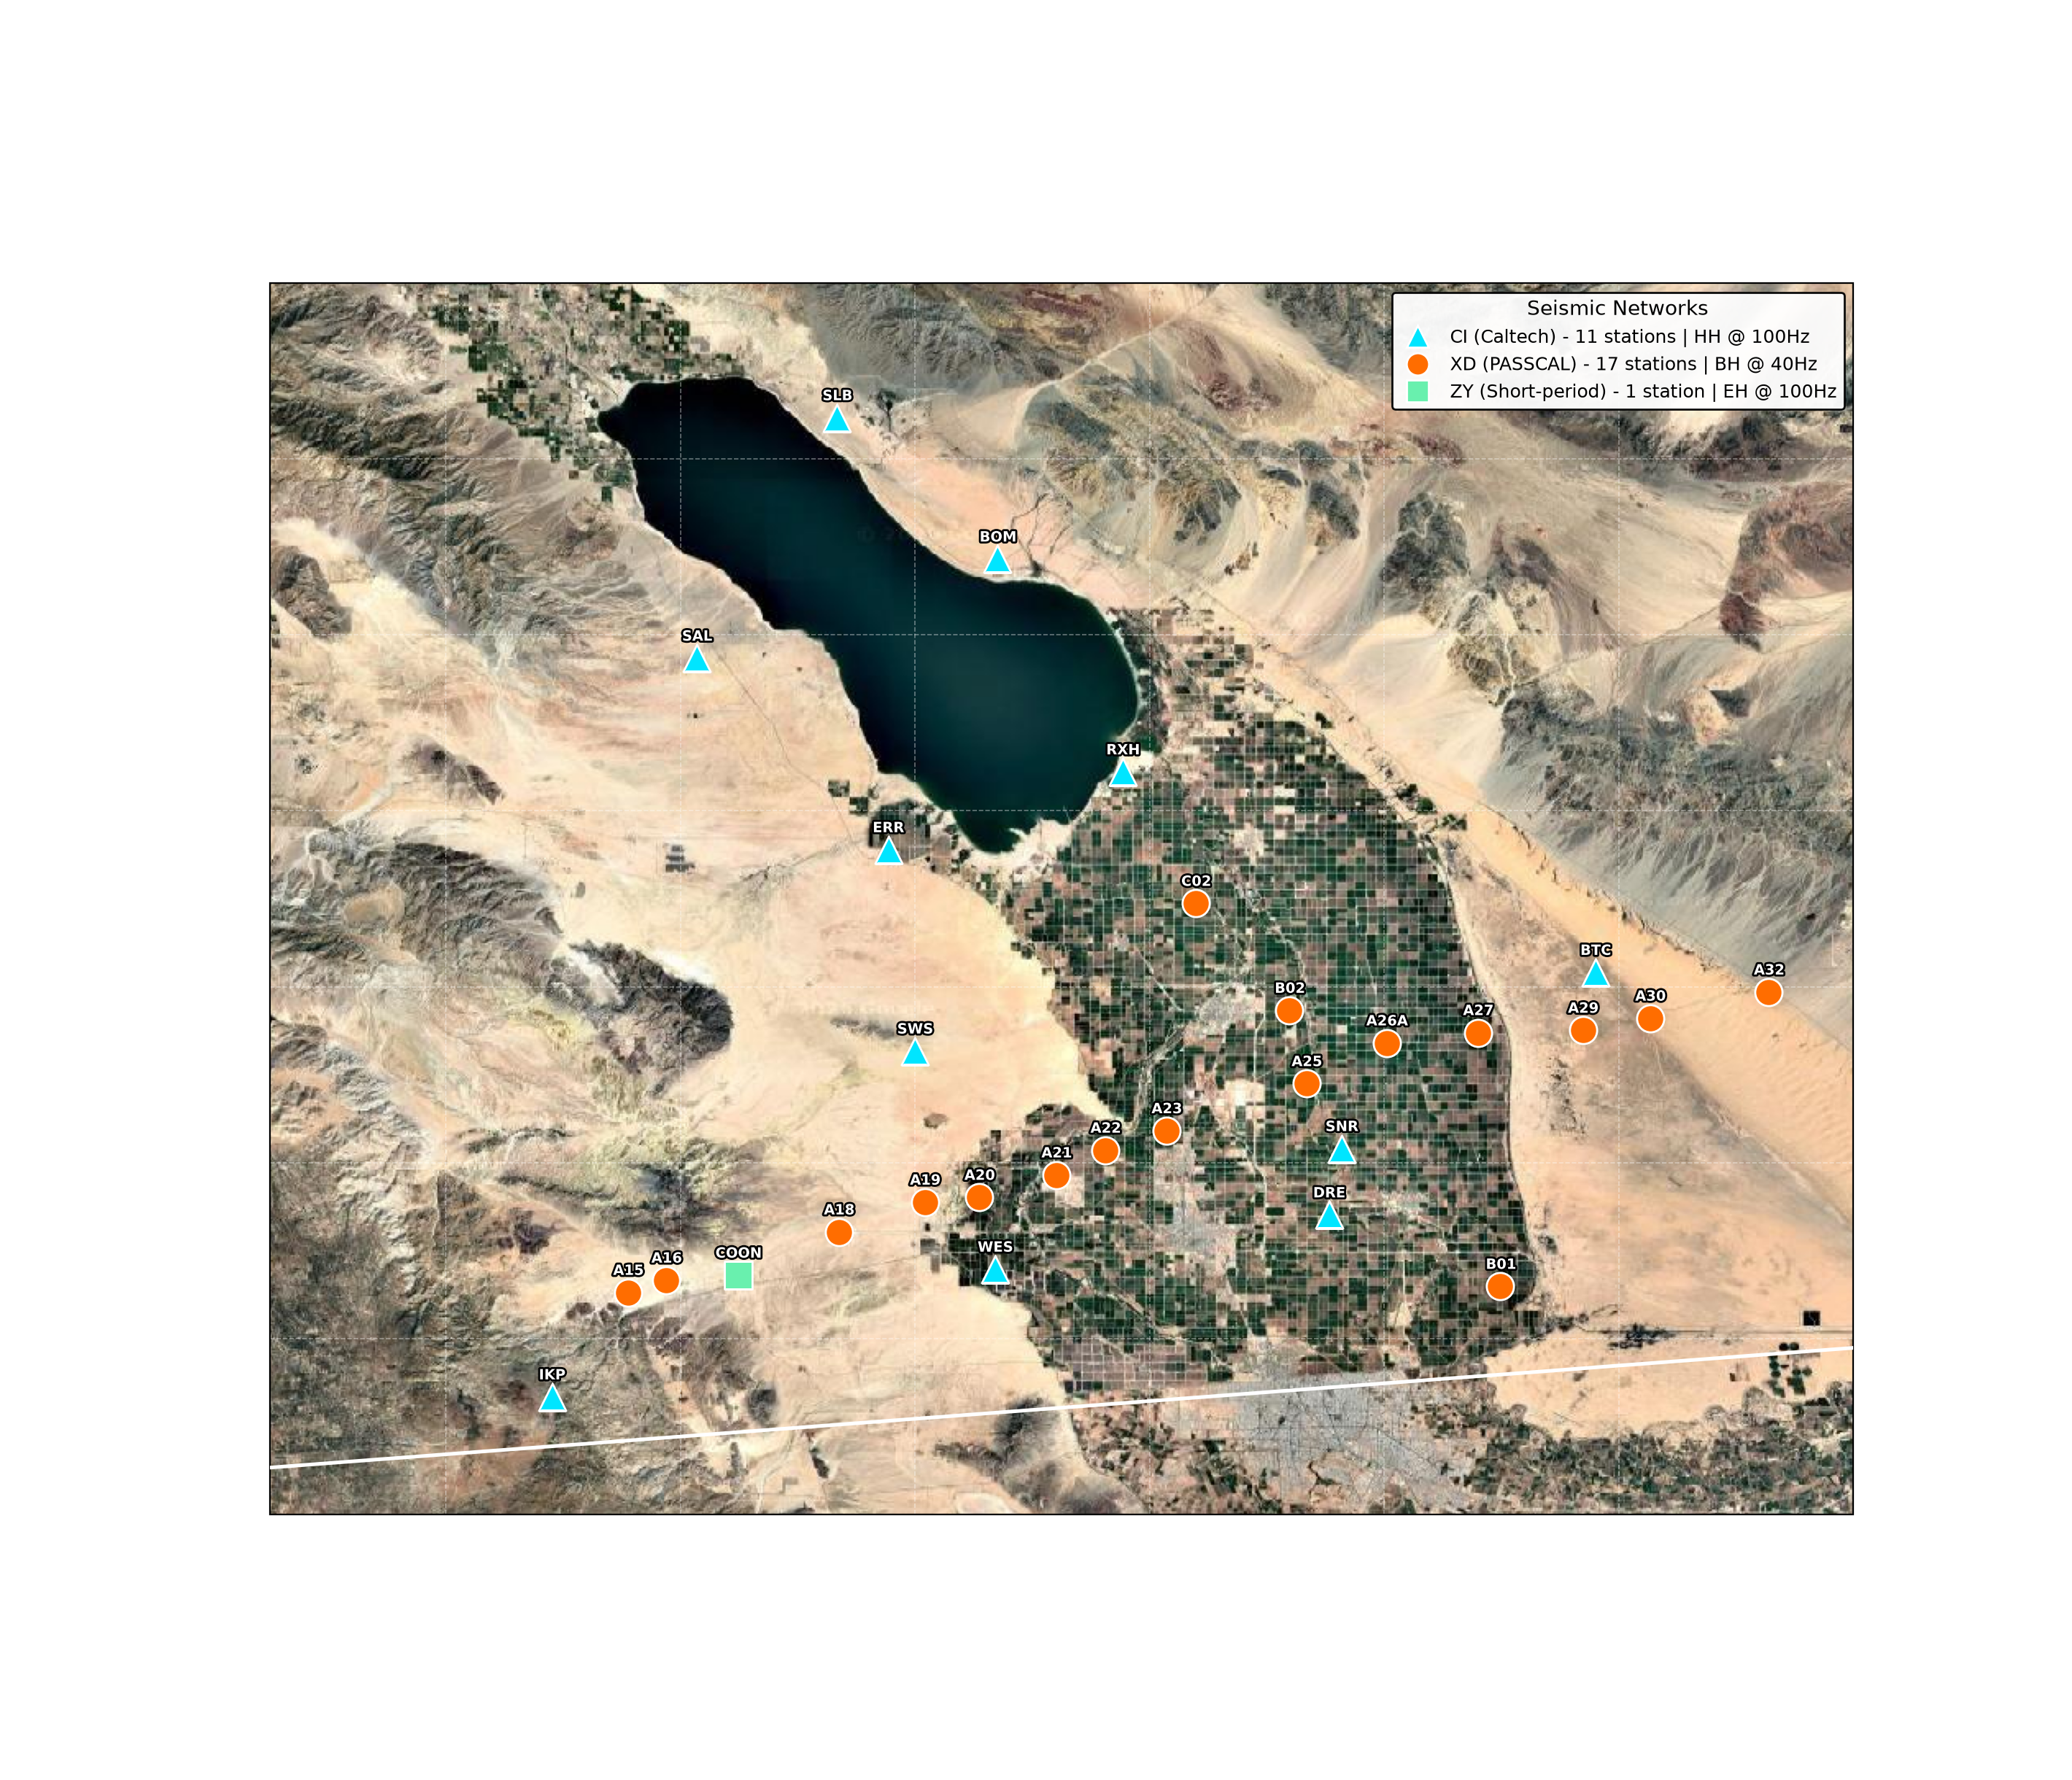


✓ Step 8 Complete


In [11]:
# Disable SSL verification (quick fix)
ssl._create_default_https_context = ssl._create_unverified_context

print("\n" + "=" * 60)
print("Step 8: Creating Network Map")
print("=" * 60)

# Generate the map
map_path = plot_station_network_map(df_sta, './Data_Salton')

print("\n✓ Step 8 Complete")

## Step 9: Compare Quiet vs Active Day Waveforms

Examine seismic recordings to see the difference between a quiet day
and the peak of the earthquake swarm. We'll load 4 hours of data from August 23 (quiet)
and August 27 (swarm peak) to visualize the increase in seismic activity.

This comparison shows:
- **Background noise levels** during normal conditions
- **Swarm activity** with continuous earthquake signals
- **Signal quality** across all three components (East, North, Vertical)

In [12]:
def load_waveform_local(date_code, station='CI.WES', hour_start=0, hour_end=4):
    """
    Load a few hours of waveform data from local directory.
    
    Parameters:
    - date_code: Date string in YYYYMMDD format
    - station: Station code in NET.STA format
    - hour_start: Starting hour (0-23)
    - hour_end: Ending hour (0-23)
    
    Returns:
    - ObsPy Stream object with filtered data
    - Station code that was actually loaded
    """
    net, sta = station.split('.')
    
    # Build path to day folder
    day_path = os.path.join(data_dir, date_code)
    
    if not os.path.exists(day_path):
        print(f'Directory not found: {day_path}')
        return None, None
    
    # Get all mseed files in directory
    all_files = sorted(glob.glob(os.path.join(day_path, '*.mseed')))
    all_names = [os.path.basename(f) for f in all_files]
    
    # Helper function to find files for a specific station
    def get_files_for_sta(n, s):
        return sorted([f for f in all_names
                       if f.startswith(f'{n}.{s}.') and f.endswith('.mseed')])
    
    # Try requested station first
    files = get_files_for_sta(net, sta)
    used_sta = station
    
    # If requested station doesn't have 3 components, find first complete station
    if len(files) < 3:
        sorted_names = sorted(all_names)
        for ns, grp in groupby(sorted_names,
                               key=lambda x: '.'.join(x.split('.')[:2])):
            grp_files = [f for f in list(grp) if f.endswith('.mseed')]
            if len(grp_files) == 3:
                files = [os.path.join(day_path, f) for f in grp_files]
                used_sta = ns
                break
    else:
        files = [os.path.join(day_path, f) for f in files]
    
    if len(files) < 3:
        print(f'No complete 3-component station found for {date_code}')
        return None, None
    
    print(f'  Loading {used_sta} from {date_code} ({len(files)} files) ...')
    
    try:
        # Read waveform files
        st = Stream()
        for fpath in files[:3]:
            st += read(fpath)
        
        # Slice to requested time window
        t0 = UTCDateTime(f'{date_code[:4]}-{date_code[4:6]}-{date_code[6:]}T00:00:00')
        st = st.slice(t0 + hour_start * 3600, t0 + hour_end * 3600)
        
        # Apply basic processing: remove mean and bandpass filter
        st = st.detrend('demean').filter('bandpass', freqmin=2, freqmax=45)
        return st, used_sta
    
    except Exception as e:
        print(f'Error loading {date_code}: {e}')
        return None, None


Step 9: Waveform Quality Assessment

Loading quiet day (Aug 23, 2012)...
  Loading CI.WES from 20120823 (3 files) ...
Loading swarm day (Aug 27, 2012)...
  Loading CI.WES from 20120827 (3 files) ...


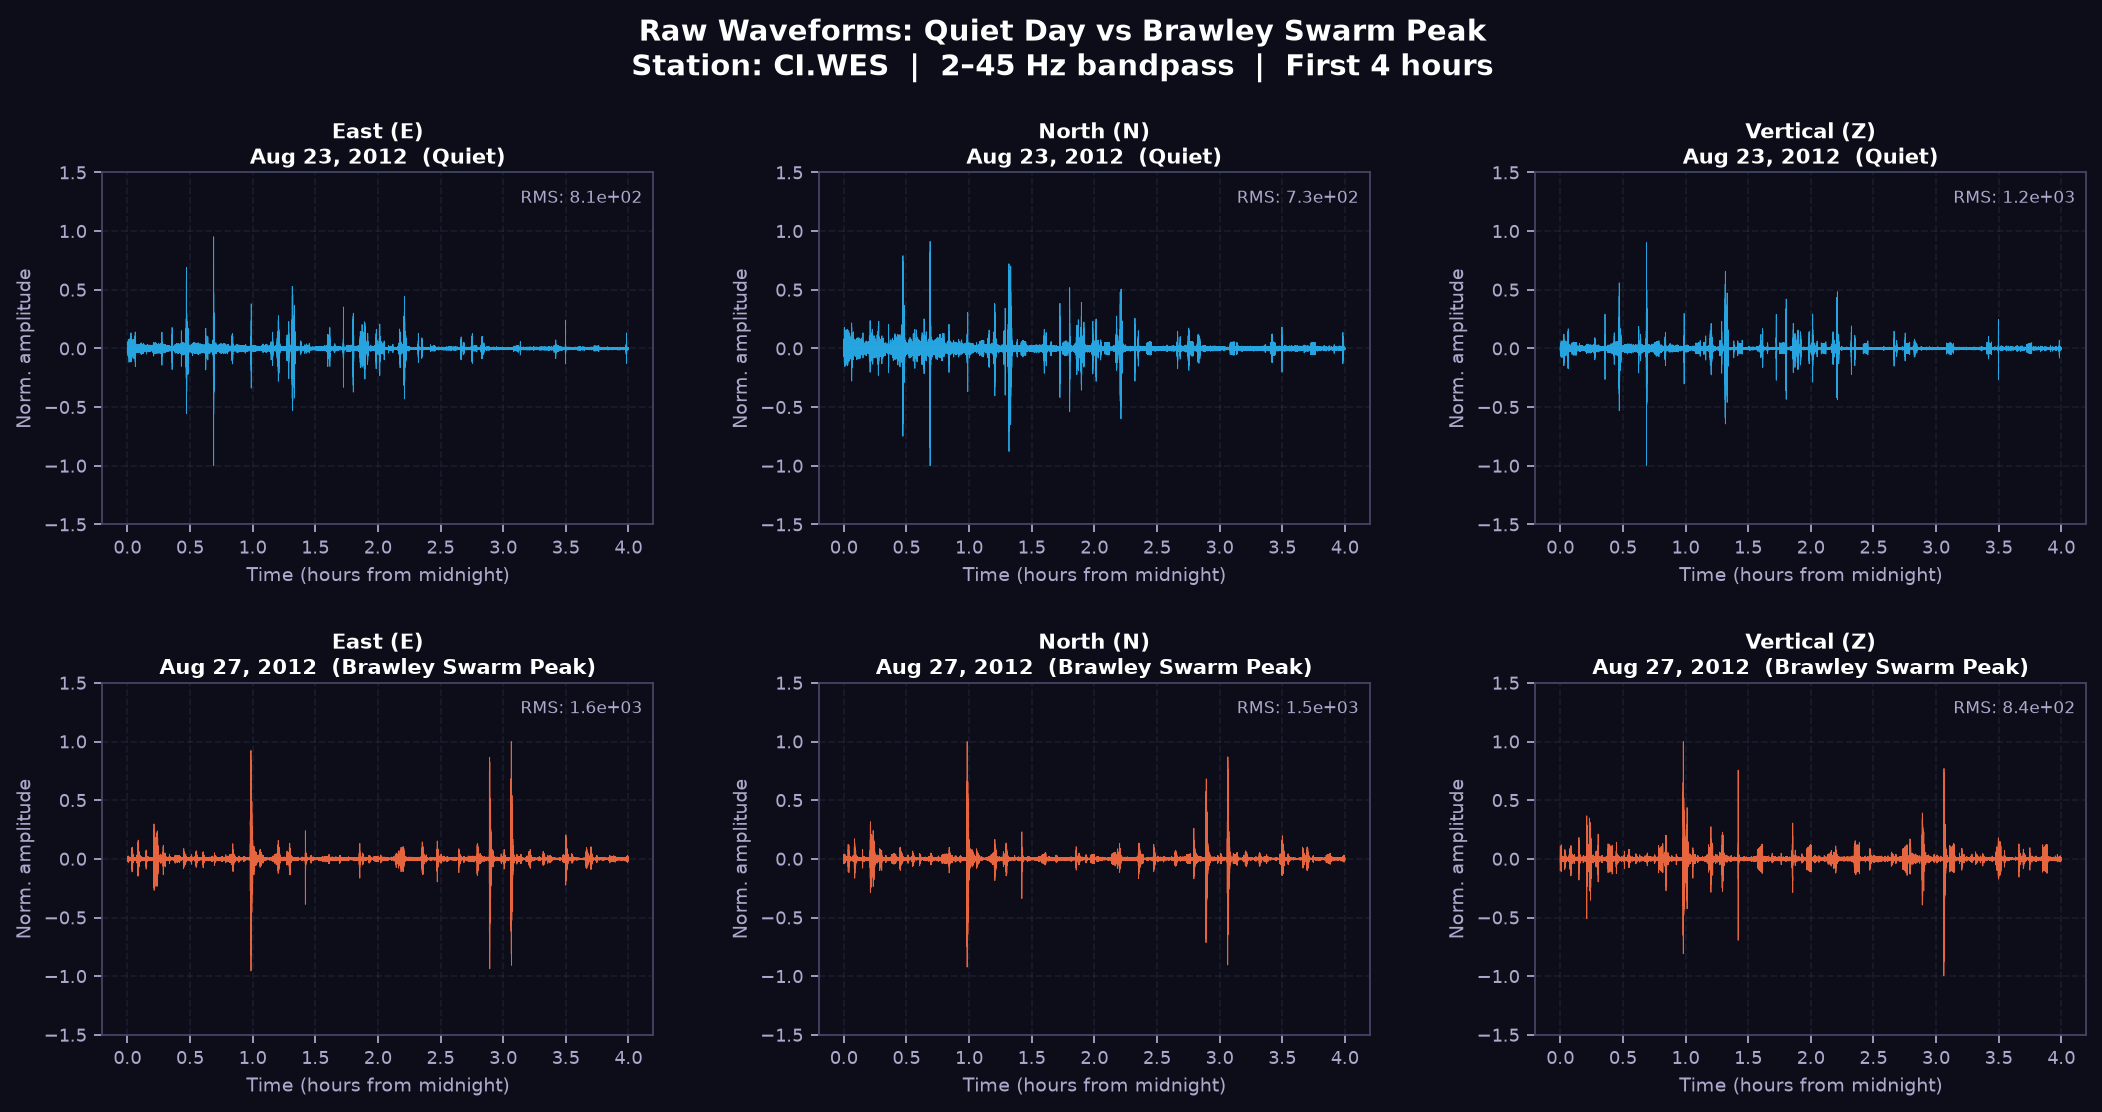


Saved: ./Data_Salton/waveform_comparison.png
Notice the Brawley Swarm day has far more high-amplitude bursts visible!

✓ Step 9 Complete - Waveform quality assessment finished


In [13]:
print("\n" + "=" * 60)
print("Step 9: Waveform Quality Assessment")
print("=" * 60)

# Load data for comparison
print('\nLoading quiet day (Aug 23, 2012)...')
st_quiet, sta_quiet = load_waveform_local('20120823', hour_start=0, hour_end=4)

print('Loading swarm day (Aug 27, 2012)...')
st_swarm, sta_swarm = load_waveform_local('20120827', hour_start=0, hour_end=4)

# Create comparison plot
fig, axes = plt.subplots(2, 3, figsize=(16, 7),
                         facecolor='#0d0d1a', 
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.3})

fig.suptitle('Raw Waveforms: Quiet Day vs Brawley Swarm Peak\n'
             f'Station: {sta_quiet or "N/A"}  |  2–45 Hz bandpass  |  First 4 hours',
             fontsize=13, fontweight='bold', color='white', y=1.02)

# Define plot parameters
chn_labels = ['East (E)', 'North (N)', 'Vertical (Z)']
row_meta = [
    (st_quiet, 'Aug 23, 2012  (Quiet)',          '#29b6f6'),
    (st_swarm, 'Aug 27, 2012  (Brawley Swarm Peak)', '#ff7043'),
]

# Plot each component for both days
for row, (st, day_label, color) in enumerate(row_meta):
    for col, chn_name in enumerate(chn_labels):
        ax = axes[row, col]
        ax.set_facecolor('#0d0d1a')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444466')

        if st is not None and len(st) > col:
            tr = st[col]
            # Convert sample indices to hours
            t = np.arange(len(tr.data)) / tr.stats.sampling_rate / 3600
            # Normalize amplitude for display
            data = tr.data / (np.max(np.abs(tr.data)) + 1e-9)
            ax.plot(t, data, color=color, linewidth=0.4, alpha=0.9)
            ax.set_ylim(-1.5, 1.5)

            # Calculate and display RMS amplitude
            rms = float(np.sqrt(np.mean(tr.data ** 2)))
            ax.text(0.98, 0.95, f'RMS: {rms:.1e}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=7.5, color='#aaaacc')
        else:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=12, color='gray')

        # Format subplot
        ax.set_title(f'{chn_name}\n{day_label}',
                     fontsize=9.5, fontweight='bold', color='white', pad=4)
        ax.set_xlabel('Time (hours from midnight)', fontsize=8.5, color='#aaaacc')
        ax.set_ylabel('Norm. amplitude', fontsize=8.5, color='#aaaacc')
        ax.tick_params(colors='#aaaacc', labelsize=8)
        ax.grid(True, alpha=0.2, color='#445566', linestyle='--')

# Save figure
out_path = os.path.join(data_dir, 'waveform_comparison.png')
plt.savefig(out_path, dpi=160, bbox_inches='tight', facecolor='#0d0d1a')

# Display the saved image
display(Image(filename=out_path))

print(f'\nSaved: {out_path}')
print('Notice the Brawley Swarm day has far more high-amplitude bursts visible!')
print("\n✓ Step 9 Complete - Waveform quality assessment finished")

## Summary

This notebook demonstrates a workflow for discovering and analyzing seismic data:

**1. Data Discovery** - Used DSI to search NDP's catalog with Python commands

**2. Metadata Exploration** - Examined dataset and file information through DSI tables

**3. Data Download** - Retrieved files from OSDF using Pelican CLI

**4. Data Analysis** - Loaded and analyzed station metadata and waveforms

**5. Visualization** - Created maps and plots to understand the network and data quality

**Key Findings:**
- 29-station network monitored the 2012 Brawley swarm
- Dense XD array provided ~3-5 km station spacing
- Observable signal difference between quiet and swarm days
- Data quality supports M0.5+ detection

**Next Steps:**
For earthquake detection and analysis workflow, see:  
https://github.com/bpari004/UCOP_Automated-Earthquake-Catalog-Salton-Sea-Geothermal-Region/tree/main